# 📈 Stock Price Prediction
### Data Science Internship — Task 2

---

**Objective:** Build machine learning models to predict future stock prices using historical data (Open, Close, High, Low, Volume).

**Models Used:**
- 📊 **Linear Regression** — Baseline model
- 🌲 **Random Forest Regressor** — Ensemble model
- 🧠 **LSTM (Long Short-Term Memory)** — Deep learning model for time-series

**Pipeline Overview:**
1. Install & Import Libraries
2. Download Historical Stock Data
3. Exploratory Data Analysis (EDA)
4. Feature Engineering
5. Data Preprocessing & Splitting
6. Model 1 — Linear Regression
7. Model 2 — Random Forest
8. Model 3 — LSTM Neural Network
9. Model Comparison & Evaluation
10. Future Price Prediction

---

## ✅ Step 1: Install & Import Libraries

We begin by installing and importing all necessary libraries:
- **`yfinance`** — Downloads real stock market data from Yahoo Finance for free.
- **`pandas` / `numpy`** — Data manipulation and numerical computation.
- **`matplotlib` / `seaborn`** — Data visualization.
- **`scikit-learn`** — Classical ML models (Linear Regression, Random Forest) and preprocessing tools.
- **`tensorflow` / `keras`** — Building and training the LSTM deep learning model.
- **`plotly`** — Interactive charts for better visualization.

In [1]:
# Install required libraries (only needed in Colab)
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn tensorflow plotly --quiet

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [2]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Data Source ──────────────────────────────────────────────────────────────
import yfinance as yf

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Scikit-learn: Preprocessing ───────────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

# ── Scikit-learn: Models ──────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Scikit-learn: Evaluation ──────────────────────────────────────────────────
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ── TensorFlow / Keras: LSTM ──────────────────────────────────────────────────
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Style Config ──────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
COLORS = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

# ── Reproducibility ───────────────────────────────────────────────────────────
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow version : {tf.__version__}")
print(f"✅ NumPy version      : {np.__version__}")
print(f"✅ Pandas version     : {pd.__version__}")
print("✅ All imports successful!")

✅ TensorFlow version : 2.19.0
✅ NumPy version      : 2.0.2
✅ Pandas version     : 2.2.2
✅ All imports successful!


---
## 📥 Step 2: Download Historical Stock Data

We use **`yfinance`** to download real historical data for **Apple Inc. (AAPL)** — one of the most actively traded stocks.

- **Ticker Symbol:** `AAPL` (you can change this to any valid ticker, e.g., `GOOGL`, `TSLA`, `MSFT`)
- **Period:** 5 years of daily OHLCV data
- **Features provided:** Open, High, Low, Close, Adj Close, Volume

> 💡 **Why AAPL?** It has high liquidity, long history, and is a great benchmark for stock prediction models.

In [3]:
# ── Configuration — change TICKER to any stock symbol you like ────────────────
TICKER      = 'AAPL'     # Stock ticker symbol
START_DATE  = '2018-01-01'
END_DATE    = '2024-12-31'
TARGET_COL  = 'Close'    # Column we want to predict

print(f"📡 Downloading {TICKER} data from {START_DATE} to {END_DATE} ...")

# yf.download() fetches OHLCV data directly from Yahoo Finance
raw_df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False)

# Flatten MultiIndex columns if present (newer yfinance versions)
if isinstance(raw_df.columns, pd.MultiIndex):
    raw_df.columns = raw_df.columns.get_level_values(0)

# Drop 'Adj Close' to avoid redundancy — we'll use raw 'Close'
raw_df.drop(columns=['Adj Close'], inplace=True, errors='ignore')

print(f"\n✅ Downloaded {len(raw_df):,} trading days of data")
print(f"📅 Date range : {raw_df.index.min().date()} → {raw_df.index.max().date()}")
print(f"📊 Columns    : {list(raw_df.columns)}")
print("\n📋 First 5 rows:")
raw_df.head()

📡 Downloading AAPL data from 2018-01-01 to 2024-12-31 ...

✅ Downloaded 1,760 trading days of data
📅 Date range : 2018-01-02 → 2024-12-30
📊 Columns    : ['Close', 'High', 'Low', 'Open', 'Volume']

📋 First 5 rows:


Price,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297153,40.839972,40.233983,40.367346,118071600
2018-01-04,40.484329,40.587278,40.262056,40.369681,89738400
2018-01-05,40.945259,41.031828,40.489013,40.580262,94640000
2018-01-08,40.793179,41.087983,40.694907,40.793179,82271200


In [4]:
# ── Basic Dataset Info ────────────────────────────────────────────────────────
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Shape         : {raw_df.shape}")
print(f"Missing values: {raw_df.isnull().sum().sum()}")
print("\n📈 Descriptive Statistics:")
raw_df.describe().round(2)

📊 DATASET OVERVIEW
Shape         : (1760, 5)
Missing values: 0

📈 Descriptive Statistics:


Price,Close,High,Low,Open,Volume
count,1760.00,1760.00,1760.00,1760.00,1.760000e+03
mean,121.66,122.87,120.32,121.54,1.001761e+08
std,59.00,59.47,58.44,58.93,5.520982e+07
min,33.77,34.61,33.72,34.19,2.323470e+07
25%,54.03,54.73,53.65,54.22,6.312485e+07
50%,131.29,132.73,129.93,131.64,8.674660e+07
75%,168.49,170.04,167.04,168.27,1.214590e+08
max,257.61,258.69,256.23,256.79,4.265100e+08


---
## 🔍 Step 3: Exploratory Data Analysis (EDA)

EDA helps us understand the structure, distribution, and patterns in our dataset **before** building any model. We will:
1. Plot the full price history (OHLC)
2. Examine trading volume over time
3. Analyze the correlation between features
4. Study daily returns distribution
5. Check for volatility using rolling statistics

These insights directly influence our feature engineering and model choices.

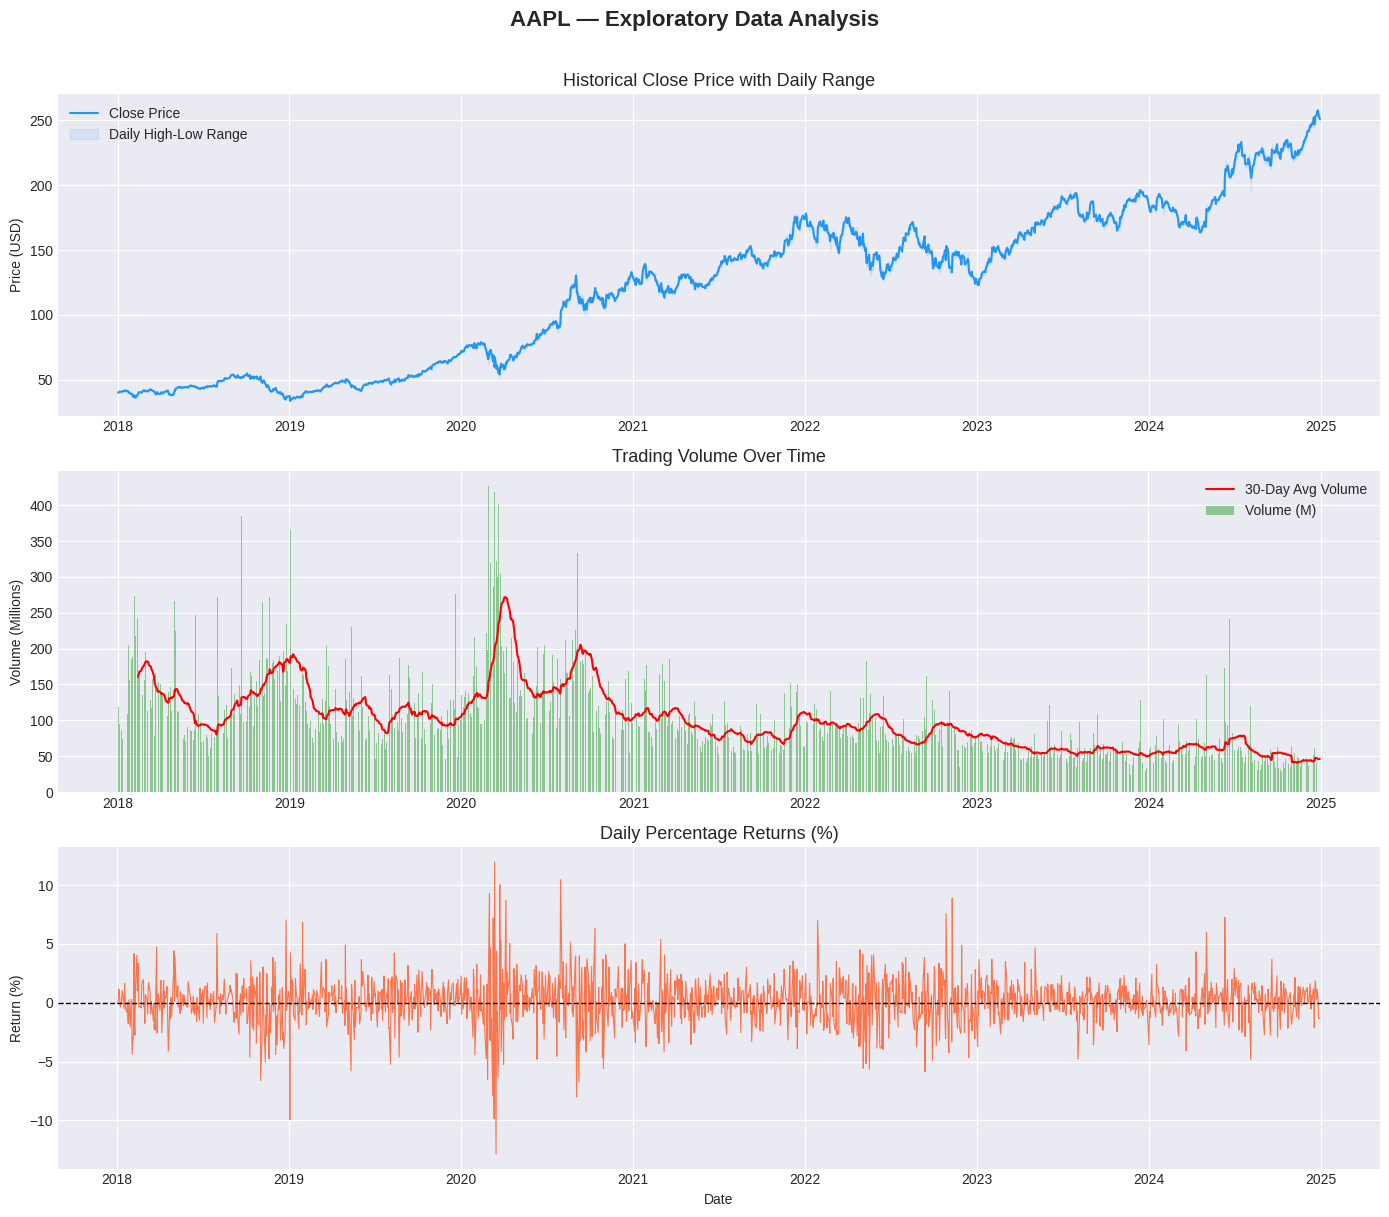


📊 Average Daily Return : 0.123%
📊 Daily Return Std Dev : 1.925%
📊 Max Single-Day Gain  : 11.98%
📊 Max Single-Day Drop  : -12.86%


In [5]:
# ── Plot 1: OHLC Price History ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle(f'{TICKER} — Exploratory Data Analysis', fontsize=16, fontweight='bold', y=1.01)

# Subplot 1: Close Price Over Time
axes[0].plot(raw_df.index, raw_df['Close'], color=COLORS[0], linewidth=1.5, label='Close Price')
axes[0].fill_between(raw_df.index, raw_df['Low'], raw_df['High'], alpha=0.1, color=COLORS[0], label='Daily High-Low Range')
axes[0].set_title('Historical Close Price with Daily Range', fontsize=13)
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Subplot 2: Trading Volume
axes[1].bar(raw_df.index, raw_df['Volume'] / 1e6, color=COLORS[1], alpha=0.6, label='Volume (M)')
vol_ma = raw_df['Volume'].rolling(30).mean() / 1e6
axes[1].plot(raw_df.index, vol_ma, color='red', linewidth=1.5, label='30-Day Avg Volume')
axes[1].set_title('Trading Volume Over Time', fontsize=13)
axes[1].set_ylabel('Volume (Millions)')
axes[1].legend()

# Subplot 3: Daily Returns
daily_returns = raw_df['Close'].pct_change().dropna() * 100
axes[2].plot(raw_df.index[1:], daily_returns, color=COLORS[2], linewidth=0.8, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Daily Percentage Returns (%)', fontsize=13)
axes[2].set_ylabel('Return (%)')
axes[2].set_xlabel('Date')

plt.tight_layout()
plt.show()
print(f"\n📊 Average Daily Return : {daily_returns.mean():.3f}%")
print(f"📊 Daily Return Std Dev : {daily_returns.std():.3f}%")
print(f"📊 Max Single-Day Gain  : {daily_returns.max():.2f}%")
print(f"📊 Max Single-Day Drop  : {daily_returns.min():.2f}%")

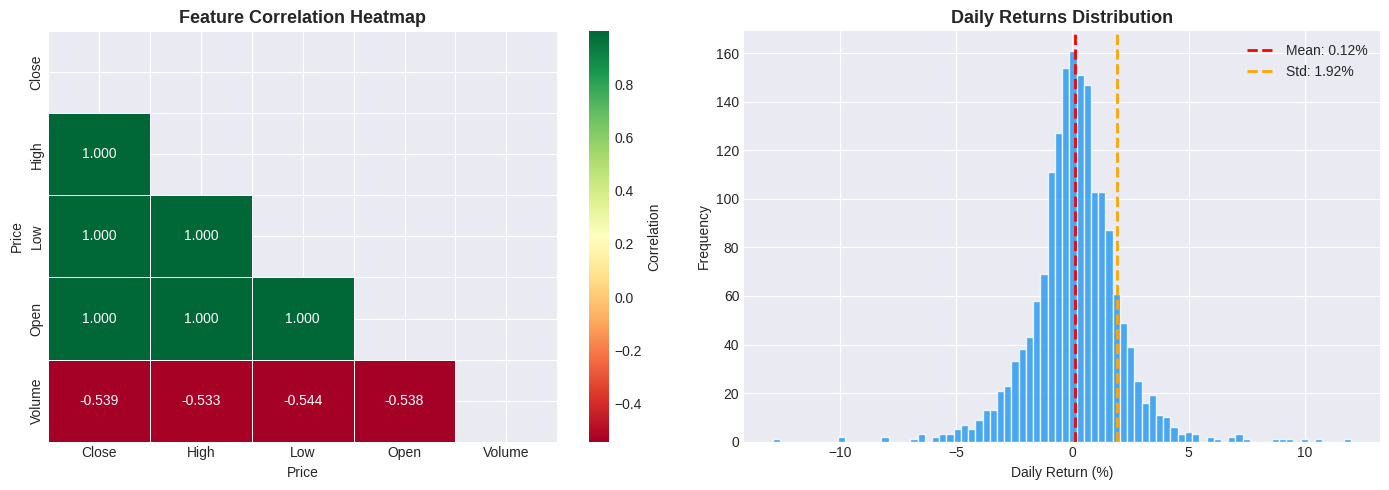


💡 Key Observations:
  • Open, High, Low, Close are highly correlated (expected for OHLC data)
  • Volume has weak correlation with price — captures independent information
  • Returns approximately follow a normal distribution with slight fat tails


In [6]:
# ── Plot 2: Correlation Heatmap & Returns Distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap — measures linear relationships between all features
corr = raw_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn',
            mask=mask, ax=axes[0], linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
axes[0].set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')

# Distribution of returns — helps understand if returns are normally distributed
axes[1].hist(daily_returns, bins=80, color=COLORS[0], edgecolor='white', alpha=0.8)
axes[1].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {daily_returns.mean():.2f}%')
axes[1].axvline(daily_returns.std(), color='orange', linestyle='--', linewidth=2, label=f'Std: {daily_returns.std():.2f}%')
axes[1].set_title('Daily Returns Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Daily Return (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n💡 Key Observations:")
print("  • Open, High, Low, Close are highly correlated (expected for OHLC data)")
print("  • Volume has weak correlation with price — captures independent information")
print("  • Returns approximately follow a normal distribution with slight fat tails")

---
## 🛠️ Step 4: Feature Engineering

Raw OHLCV data alone is limited. We engineer **technical indicators** — widely used by traders and ML models — to capture trend, momentum, and volatility signals:

| Feature | Description |
|---|---|
| `MA_7`, `MA_21`, `MA_50` | Simple Moving Averages — smoothed price trends |
| `EMA_12`, `EMA_26` | Exponential Moving Averages — weight recent prices more |
| `MACD`, `MACD_Signal` | Momentum indicator (EMA12 - EMA26) |
| `RSI` | Relative Strength Index — overbought/oversold (0–100) |
| `BB_Upper`, `BB_Lower` | Bollinger Bands — volatility-based price bands |
| `ATR` | Average True Range — market volatility |
| `OBV` | On-Balance Volume — volume-based trend strength |
| `Price_Change`, `Return` | Daily change and percentage return |
| `Volatility_7d` | Rolling 7-day return standard deviation |
| `High_Low_Ratio` | Intraday price range ratio |

> 💡 Good features are the **single biggest factor** in ML model performance.

In [7]:
def engineer_features(df):
    """
    Compute technical indicators and derived features.
    All calculations use only past data to avoid lookahead bias.
    """
    d = df.copy()

    # ── Moving Averages ────────────────────────────────────────────────────────
    # SMA: equal weight to all periods in the window
    d['MA_7']  = d['Close'].rolling(window=7).mean()
    d['MA_21'] = d['Close'].rolling(window=21).mean()
    d['MA_50'] = d['Close'].rolling(window=50).mean()

    # EMA: exponentially decaying weights — reacts faster to recent price changes
    d['EMA_12'] = d['Close'].ewm(span=12, adjust=False).mean()
    d['EMA_26'] = d['Close'].ewm(span=26, adjust=False).mean()

    # ── MACD (Moving Average Convergence Divergence) ───────────────────────────
    # MACD > 0 → bullish momentum; MACD < 0 → bearish
    d['MACD']        = d['EMA_12'] - d['EMA_26']
    d['MACD_Signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_Hist']   = d['MACD'] - d['MACD_Signal']

    # ── RSI (Relative Strength Index) ─────────────────────────────────────────
    # RSI > 70 → possibly overbought; RSI < 30 → possibly oversold
    delta   = d['Close'].diff()
    gain    = delta.clip(lower=0)
    loss    = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs       = avg_gain / (avg_loss + 1e-10)   # small epsilon prevents div-by-zero
    d['RSI'] = 100 - (100 / (1 + rs))

    # ── Bollinger Bands ───────────────────────────────────────────────────────
    # Bands = MA ± 2 standard deviations; captures price volatility
    bb_mid       = d['Close'].rolling(20).mean()
    bb_std       = d['Close'].rolling(20).std()
    d['BB_Upper']    = bb_mid + 2 * bb_std
    d['BB_Lower']    = bb_mid - 2 * bb_std
    d['BB_Width']    = (d['BB_Upper'] - d['BB_Lower']) / bb_mid  # normalized width
    d['BB_Position'] = (d['Close'] - d['BB_Lower']) / (d['BB_Upper'] - d['BB_Lower'] + 1e-10)

    # ── ATR (Average True Range) ──────────────────────────────────────────────
    # Measures market volatility regardless of direction
    high_low   = d['High'] - d['Low']
    high_close = (d['High'] - d['Close'].shift()).abs()
    low_close  = (d['Low']  - d['Close'].shift()).abs()
    true_range = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    d['ATR']   = true_range.rolling(14).mean()

    # ── OBV (On-Balance Volume) ───────────────────────────────────────────────
    # Cumulative sum: +Volume on up days, -Volume on down days
    obv   = [0]
    close = d['Close'].values
    vol   = d['Volume'].values
    for i in range(1, len(close)):
        if close[i] > close[i-1]:
            obv.append(obv[-1] + vol[i])
        elif close[i] < close[i-1]:
            obv.append(obv[-1] - vol[i])
        else:
            obv.append(obv[-1])
    d['OBV'] = obv

    # ── Price & Return Features ───────────────────────────────────────────────
    d['Price_Change']  = d['Close'].diff()           # Absolute daily change
    d['Return']        = d['Close'].pct_change()      # Percentage daily return
    d['Volatility_7d'] = d['Return'].rolling(7).std() # 7-day rolling volatility
    d['High_Low_Ratio']= d['High'] / (d['Low'] + 1e-10)  # Intraday range
    d['Close_Open_Ratio'] = d['Close'] / (d['Open'] + 1e-10)  # Body ratio

    # ── Lag Features — past Close values as features ──────────────────────────
    # Giving the model "memory" of recent prices
    for lag in [1, 2, 3, 5, 10]:
        d[f'Close_Lag_{lag}'] = d['Close'].shift(lag)

    return d


# Apply feature engineering
df = engineer_features(raw_df)

# Drop rows with NaN values introduced by rolling windows and lags
df.dropna(inplace=True)

print(f"✅ Feature engineering complete!")
print(f"📊 Original features : {raw_df.shape[1]}")
print(f"📊 After engineering : {df.shape[1]} features")
print(f"📊 Dataset shape     : {df.shape}")
print(f"\n📋 All features:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2d}. {col}")

✅ Feature engineering complete!
📊 Original features : 5
📊 After engineering : 30 features
📊 Dataset shape     : (1711, 30)

📋 All features:
    1. Close
    2. High
    3. Low
    4. Open
    5. Volume
    6. MA_7
    7. MA_21
    8. MA_50
    9. EMA_12
   10. EMA_26
   11. MACD
   12. MACD_Signal
   13. MACD_Hist
   14. RSI
   15. BB_Upper
   16. BB_Lower
   17. BB_Width
   18. BB_Position
   19. ATR
   20. OBV
   21. Price_Change
   22. Return
   23. Volatility_7d
   24. High_Low_Ratio
   25. Close_Open_Ratio
   26. Close_Lag_1
   27. Close_Lag_2
   28. Close_Lag_3
   29. Close_Lag_5
   30. Close_Lag_10


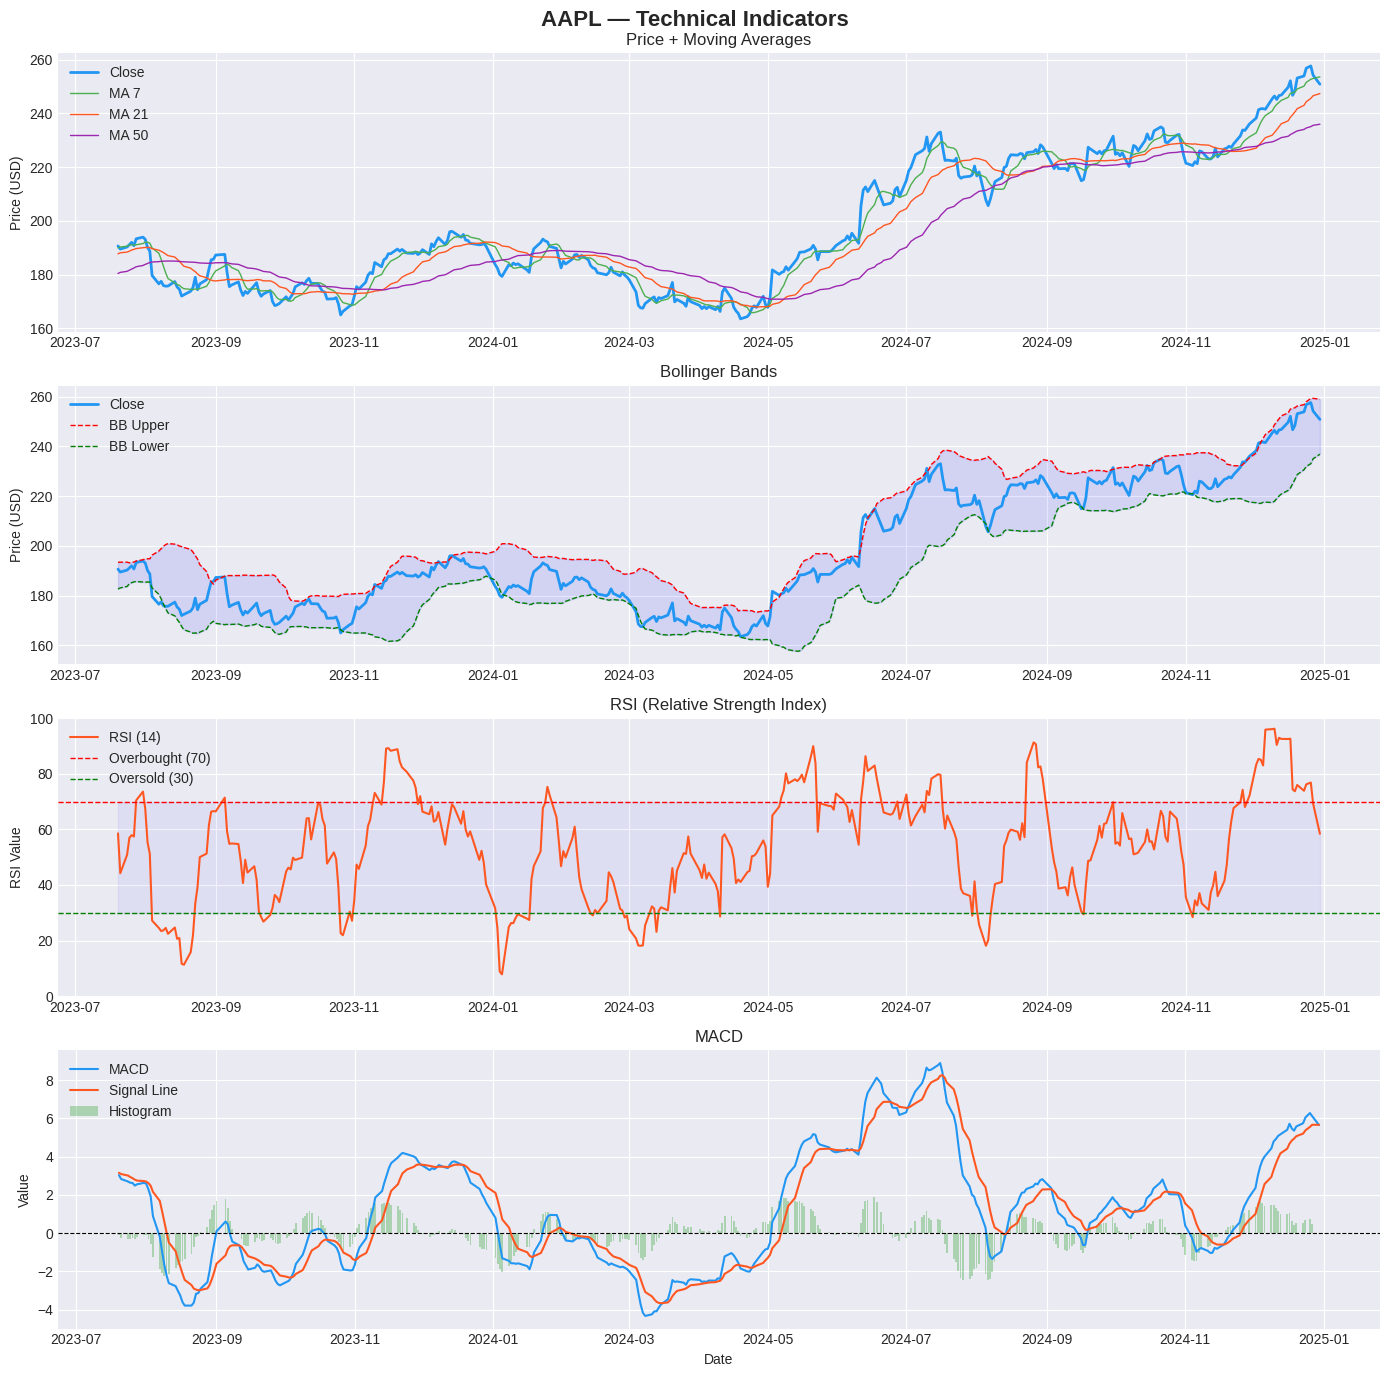

In [8]:
# ── Visualize Key Technical Indicators ─────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle(f'{TICKER} — Technical Indicators', fontsize=16, fontweight='bold')

# Plot last 365 days for clarity
plot_df = df.iloc[-365:]

# 1. Close + Moving Averages
axes[0].plot(plot_df.index, plot_df['Close'],  label='Close',  color=COLORS[0], linewidth=2)
axes[0].plot(plot_df.index, plot_df['MA_7'],   label='MA 7',   color=COLORS[1], linewidth=1)
axes[0].plot(plot_df.index, plot_df['MA_21'],  label='MA 21',  color=COLORS[2], linewidth=1)
axes[0].plot(plot_df.index, plot_df['MA_50'],  label='MA 50',  color=COLORS[3], linewidth=1)
axes[0].set_title('Price + Moving Averages')
axes[0].set_ylabel('Price (USD)')
axes[0].legend(loc='upper left')

# 2. Bollinger Bands
axes[1].plot(plot_df.index, plot_df['Close'],    label='Close',       color=COLORS[0], linewidth=2)
axes[1].plot(plot_df.index, plot_df['BB_Upper'], label='BB Upper',    color='red',   linewidth=1, linestyle='--')
axes[1].plot(plot_df.index, plot_df['BB_Lower'], label='BB Lower',    color='green', linewidth=1, linestyle='--')
axes[1].fill_between(plot_df.index, plot_df['BB_Lower'], plot_df['BB_Upper'], alpha=0.1, color='blue')
axes[1].set_title('Bollinger Bands')
axes[1].set_ylabel('Price (USD)')
axes[1].legend(loc='upper left')

# 3. RSI
axes[2].plot(plot_df.index, plot_df['RSI'], color=COLORS[2], linewidth=1.5, label='RSI (14)')
axes[2].axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].fill_between(plot_df.index, 30, 70, alpha=0.05, color='blue')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (Relative Strength Index)')
axes[2].set_ylabel('RSI Value')
axes[2].legend(loc='upper left')

# 4. MACD
axes[3].plot(plot_df.index, plot_df['MACD'],        label='MACD',        color=COLORS[0], linewidth=1.5)
axes[3].plot(plot_df.index, plot_df['MACD_Signal'], label='Signal Line', color=COLORS[2], linewidth=1.5)
axes[3].bar(plot_df.index,  plot_df['MACD_Hist'],   label='Histogram',   color=COLORS[1], alpha=0.4)
axes[3].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[3].set_title('MACD')
axes[3].set_ylabel('Value')
axes[3].set_xlabel('Date')
axes[3].legend(loc='upper left')

plt.tight_layout()
plt.show()

---
## ⚙️ Step 5: Data Preprocessing & Splitting

Before training, we must prepare data properly:

1. **Define Features (X) and Target (y):** Our target is the **next day's closing price** (shifted by 1).
2. **Temporal Train/Test Split:** We split chronologically (80/20) — never shuffle time-series data, as it would leak future information into training.
3. **Normalization (MinMaxScaler):** ML models (especially neural networks) converge faster when features are on the same scale [0, 1].
4. **LSTM Sequence Creation:** LSTMs expect 3D input `(samples, timesteps, features)` — we create sliding windows of `LOOK_BACK` days.

In [9]:
# ── Configuration ─────────────────────────────────────────────────────────────
LOOK_BACK   = 60    # Number of past days the LSTM 'looks back' at
TEST_RATIO  = 0.20  # 20% of data held out for testing

# ── Target Variable: Next Day's Close Price ───────────────────────────────────
# Shift Close by -1 so the model learns to predict tomorrow's price from today's features
df['Target'] = df['Close'].shift(-1)
df.dropna(inplace=True)   # Remove last row (no tomorrow for it)

# ── Feature Selection ─────────────────────────────────────────────────────────
# Exclude the raw target from features to prevent direct data leakage
FEATURE_COLS = [c for c in df.columns if c != 'Target']

X = df[FEATURE_COLS].values
y = df['Target'].values

# ── Chronological Train/Test Split ───────────────────────────────────────────
split_idx   = int(len(X) * (1 - TEST_RATIO))
X_train_raw = X[:split_idx]
X_test_raw  = X[split_idx:]
y_train     = y[:split_idx]
y_test      = y[split_idx:]

train_dates = df.index[:split_idx]
test_dates  = df.index[split_idx:]

print("=" * 50)
print("⚙️  DATA SPLIT SUMMARY")
print("=" * 50)
print(f"Total samples   : {len(X):,}")
print(f"Training samples: {len(X_train_raw):,}  ({(1-TEST_RATIO)*100:.0f}%)")
print(f"Testing samples : {len(X_test_raw):,}  ({TEST_RATIO*100:.0f}%)")
print(f"Feature count   : {X.shape[1]}")
print(f"Train period    : {train_dates[0].date()} → {train_dates[-1].date()}")
print(f"Test period     : {test_dates[0].date()} → {test_dates[-1].date()}")

⚙️  DATA SPLIT SUMMARY
Total samples   : 1,710
Training samples: 1,368  (80%)
Testing samples : 342  (20%)
Feature count   : 30
Train period    : 2018-03-14 → 2023-08-18
Test period     : 2023-08-21 → 2024-12-27


In [10]:
# ── Feature Scaling (MinMaxScaler) ────────────────────────────────────────────
# IMPORTANT: Fit scaler on TRAINING data only, then transform both sets.
# Fitting on the full dataset would introduce data leakage from the test set.

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train_raw)
X_test_scaled  = scaler_X.transform(X_test_raw)       # Use training scaler parameters

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"✅ Features scaled to range [0, 1]")
print(f"   X_train_scaled : {X_train_scaled.shape}")
print(f"   X_test_scaled  : {X_test_scaled.shape}")

# ── LSTM Sequence Builder ─────────────────────────────────────────────────────
def create_sequences(X, y, look_back):
    """
    Convert flat 2D arrays into 3D sequences for LSTM.
    Each sample = look_back consecutive days of features → 1 target value.

    Returns:
        Xs : shape (n_samples, look_back, n_features)
        ys : shape (n_samples,)
    """
    Xs, ys = [], []
    for i in range(look_back, len(X)):
        Xs.append(X[i - look_back : i])   # Sliding window of past 'look_back' rows
        ys.append(y[i])                    # Corresponding target
    return np.array(Xs), np.array(ys)


X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, LOOK_BACK)
X_test_seq,  y_test_seq  = create_sequences(X_test_scaled,  y_test_scaled,  LOOK_BACK)

# Align test labels (trim first LOOK_BACK rows lost to windowing)
y_test_trimmed = y_test[LOOK_BACK:]
test_dates_trimmed = test_dates[LOOK_BACK:]

print(f"\n✅ LSTM Sequences created with LOOK_BACK = {LOOK_BACK} days")
print(f"   X_train_seq : {X_train_seq.shape}  → (samples, timesteps, features)")
print(f"   X_test_seq  : {X_test_seq.shape}")

✅ Features scaled to range [0, 1]
   X_train_scaled : (1368, 30)
   X_test_scaled  : (342, 30)

✅ LSTM Sequences created with LOOK_BACK = 60 days
   X_train_seq : (1308, 60, 30)  → (samples, timesteps, features)
   X_test_seq  : (282, 60, 30)


---
## 📊 Step 6: Model 1 — Linear Regression (Baseline)

**Linear Regression** models the relationship between features and the target as a weighted linear sum:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

**Why use it as a baseline?**
- Very fast to train — establishes a performance floor.
- If complex models barely beat it, the problem might be inherently linear.
- Easy to interpret the coefficient weights.

**Limitation:** Assumes a linear relationship — stock prices are non-linear and path-dependent, so we expect this to underperform.

In [11]:
print("🔵 Training Linear Regression ...")

# Linear Regression doesn't need scaled targets for interpretability,
# but we use scaled features for numerical stability
lr_model = LinearRegression(n_jobs=-1)   # n_jobs=-1 uses all CPU cores
lr_model.fit(X_train_scaled, y_train)

# Predict on test set
lr_pred_test  = lr_model.predict(X_test_scaled)
lr_pred_train = lr_model.predict(X_train_scaled)

# ── Evaluation Metrics ────────────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, model_name, split='Test'):
    """Compute and display regression evaluation metrics."""
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100
    r2   = r2_score(y_true, y_pred)

    print(f"\n{'='*45}")
    print(f"  {model_name} — {split} Set Metrics")
    print(f"{'='*45}")
    print(f"  MAE  (Mean Absolute Error)       : ${mae:.4f}")
    print(f"  MSE  (Mean Squared Error)        : ${mse:.4f}")
    print(f"  RMSE (Root Mean Squared Error)   : ${rmse:.4f}")
    print(f"  MAPE (Mean Abs Percentage Error) : {mape:.4f}%")
    print(f"  R²   (Coefficient of Det.)       : {r2:.6f}")

    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}


lr_results = evaluate_model(y_test, lr_pred_test, 'Linear Regression')
print("\n✅ Linear Regression training complete!")

🔵 Training Linear Regression ...

  Linear Regression — Test Set Metrics
  MAE  (Mean Absolute Error)       : $2.0458
  MSE  (Mean Squared Error)        : $7.6105
  RMSE (Root Mean Squared Error)   : $2.7587
  MAPE (Mean Abs Percentage Error) : 1.0315%
  R²   (Coefficient of Det.)       : 0.987607

✅ Linear Regression training complete!


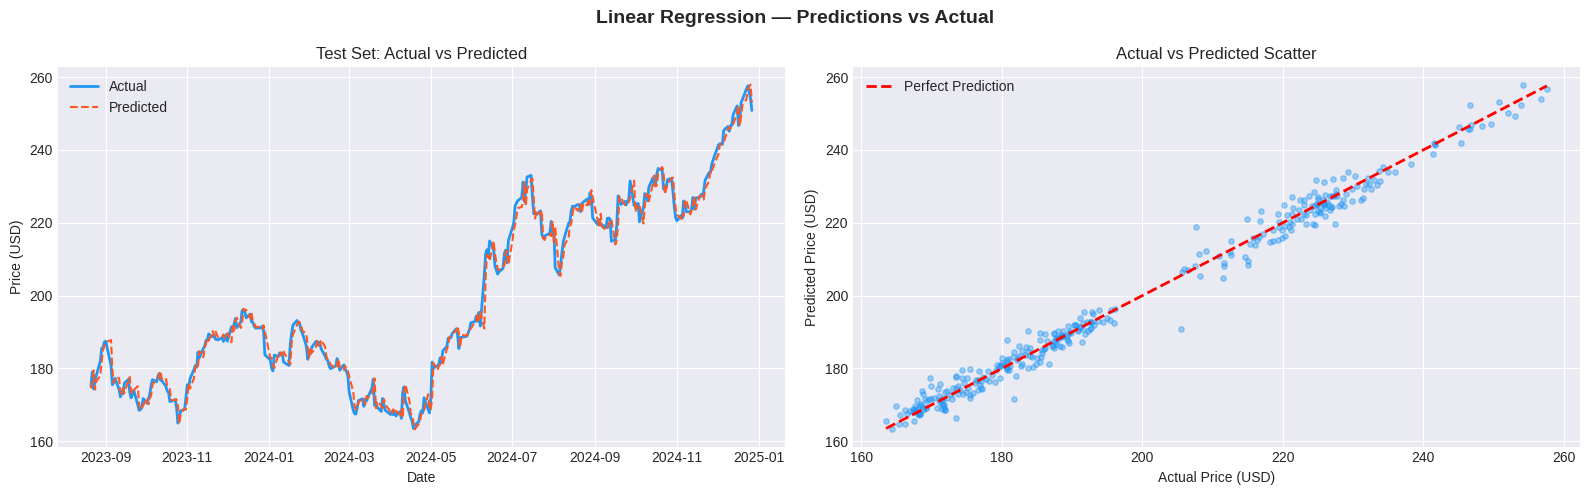

In [12]:
# ── Plot Linear Regression Predictions ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Linear Regression — Predictions vs Actual', fontsize=14, fontweight='bold')

# Time-series comparison
axes[0].plot(test_dates, y_test,        label='Actual',     color=COLORS[0], linewidth=2)
axes[0].plot(test_dates, lr_pred_test,  label='Predicted',  color=COLORS[2], linewidth=1.5, linestyle='--')
axes[0].set_title('Test Set: Actual vs Predicted')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()

# Scatter plot — perfect predictions lie on the diagonal
axes[1].scatter(y_test, lr_pred_test, alpha=0.4, color=COLORS[0], s=15)
min_val, max_val = y_test.min(), y_test.max()
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted Scatter')
axes[1].set_xlabel('Actual Price (USD)')
axes[1].set_ylabel('Predicted Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

---
## 🌲 Step 7: Model 2 — Random Forest Regressor

**Random Forest** is an ensemble of many decision trees trained on random subsets of data and features (bagging). The final prediction averages all tree outputs:

$$\hat{y} = \frac{1}{T} \sum_{t=1}^{T} h_t(x)$$

**Key Hyperparameters:**
- `n_estimators=200` — Number of trees; more = better but slower.
- `max_depth=20` — Max tree depth; controls overfitting.
- `min_samples_leaf=5` — Minimum samples per leaf; prevents overfitting.
- `max_features='sqrt'` — Features per split; adds randomness.

**Advantages:** Handles non-linearity, robust to outliers, provides feature importance rankings.

In [13]:
print("🌲 Training Random Forest (this may take ~30 seconds) ...")

rf_model = RandomForestRegressor(
    n_estimators  = 200,    # 200 trees in the forest
    max_depth     = 20,     # Cap depth to reduce overfitting
    min_samples_leaf = 5,   # Each leaf must have at least 5 samples
    max_features  = 'sqrt', # Use sqrt(n_features) features per split
    random_state  = 42,
    n_jobs        = -1      # Parallel training on all cores
)

rf_model.fit(X_train_scaled, y_train)

rf_pred_test  = rf_model.predict(X_test_scaled)
rf_pred_train = rf_model.predict(X_train_scaled)

rf_results = evaluate_model(y_test, rf_pred_test, 'Random Forest')
print("\n✅ Random Forest training complete!")

🌲 Training Random Forest (this may take ~30 seconds) ...

  Random Forest — Test Set Metrics
  MAE  (Mean Absolute Error)       : $16.3860
  MSE  (Mean Squared Error)        : $603.3074
  RMSE (Root Mean Squared Error)   : $24.5623
  MAPE (Mean Abs Percentage Error) : 7.3231%
  R²   (Coefficient of Det.)       : 0.017550

✅ Random Forest training complete!


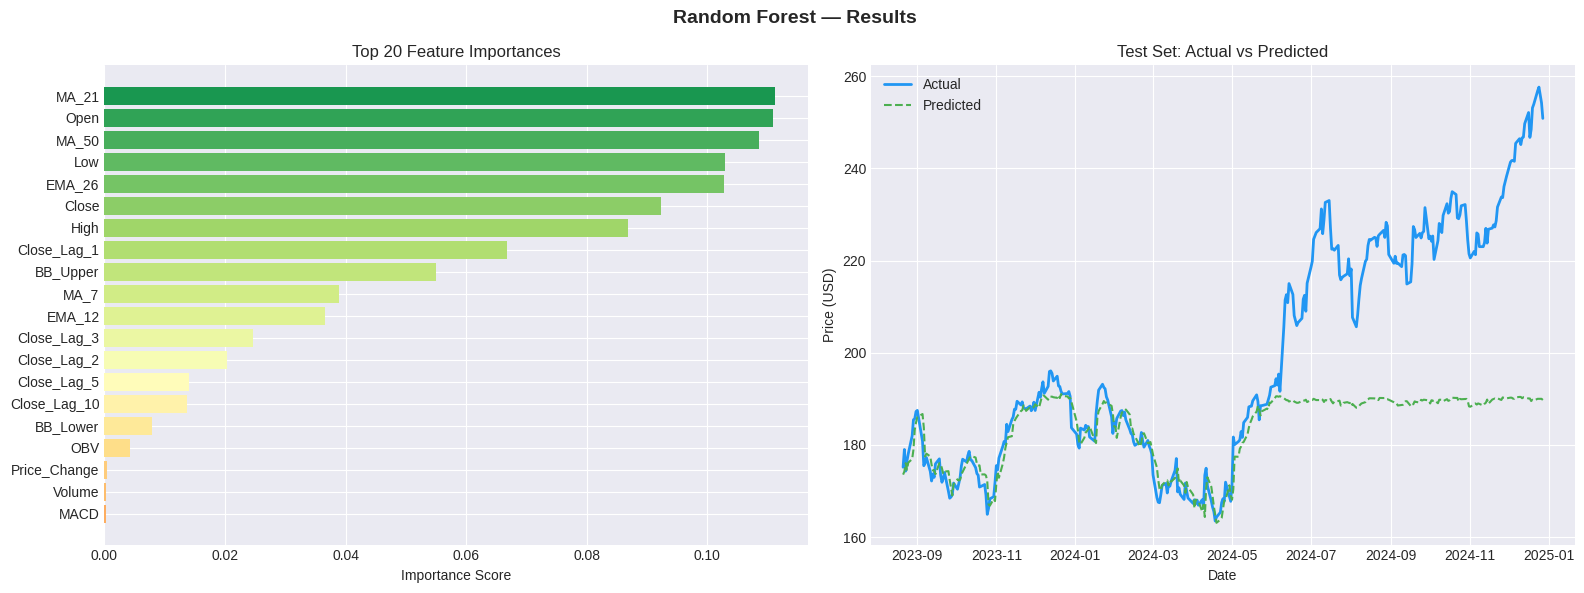


🏆 Top 10 Most Important Features:
    Feature  Importance
      MA_21    0.111226
       Open    0.111011
      MA_50    0.108551
        Low    0.103028
     EMA_26    0.102776
      Close    0.092352
       High    0.086837
Close_Lag_1    0.066873
   BB_Upper    0.054937
       MA_7    0.038911


In [14]:
# ── Feature Importance Plot ───────────────────────────────────────────────────
# Random Forest naturally computes feature importance — how much each feature
# reduces impurity when used in splits, averaged across all trees.

importances = rf_model.feature_importances_
feat_df     = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
feat_df     = feat_df.sort_values('Importance', ascending=True).tail(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Random Forest — Results', fontsize=14, fontweight='bold')

# Feature Importance Bar Chart
bars = axes[0].barh(feat_df['Feature'], feat_df['Importance'],
                    color=plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(feat_df))))
axes[0].set_title('Top 20 Feature Importances')
axes[0].set_xlabel('Importance Score')

# Prediction vs Actual
axes[1].plot(test_dates, y_test,       label='Actual',    color=COLORS[0], linewidth=2)
axes[1].plot(test_dates, rf_pred_test, label='Predicted', color=COLORS[1], linewidth=1.5, linestyle='--')
axes[1].set_title('Test Set: Actual vs Predicted')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n🏆 Top 10 Most Important Features:")
print(feat_df.sort_values('Importance', ascending=False).head(10).to_string(index=False))

---
## 🧠 Step 8: Model 3 — LSTM Neural Network

**LSTM (Long Short-Term Memory)** is a type of Recurrent Neural Network (RNN) designed to learn **long-range temporal dependencies** in sequential data — perfect for stock prices.

**Architecture:**
```
Input (60 days × N features)
      ↓
LSTM Layer 1 (128 units, return_sequences=True) + Dropout(0.2)
      ↓
LSTM Layer 2 (64 units, return_sequences=False) + Dropout(0.2)
      ↓
Dense Layer (32 units, ReLU)
      ↓
Output Layer (1 unit — next day Close price)
```

**Key LSTM Concepts:**
- **Cell State (Cₜ):** Long-term memory highway.
- **Forget Gate (fₜ):** Decides what to discard from memory.
- **Input Gate (iₜ):** Decides what new info to add.
- **Output Gate (oₜ):** Controls what part of memory to output.
- **Dropout:** Randomly zeroes units during training to prevent overfitting.
- **EarlyStopping:** Stops training when validation loss stops improving.

In [15]:
print("🧠 Building LSTM Model ...")

n_features = X_train_seq.shape[2]   # Number of features

# ── Model Architecture ────────────────────────────────────────────────────────
lstm_model = Sequential([
    # Layer 1: LSTM with 128 units
    # return_sequences=True passes the full sequence to the next LSTM layer
    LSTM(128, return_sequences=True, input_shape=(LOOK_BACK, n_features)),
    Dropout(0.2),       # Drop 20% of neurons randomly to prevent overfitting
    BatchNormalization(),# Normalize activations for faster, more stable training

    # Layer 2: LSTM with 64 units
    # return_sequences=False returns only the last timestep output
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),

    # Fully connected layer
    Dense(32, activation='relu'),
    Dropout(0.1),

    # Output: single continuous value (predicted normalized price)
    Dense(1, activation='linear')
])

# ── Compile ───────────────────────────────────────────────────────────────────
# Adam optimizer adapts learning rate during training
lstm_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'huber',    # Huber loss is less sensitive to outliers than MSE
    metrics   = ['mae']
)

lstm_model.summary()

🧠 Building LSTM Model ...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        81,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 133,697 (522.25 KB)

 Trainable params: 133,313 (520.75 KB)

 Non-trainable params: 384 (1.50 KB)

In [16]:
print("🏋️ Training LSTM (may take 2-5 minutes on CPU, ~30 sec on GPU) ...\n")

# ── Callbacks ─────────────────────────────────────────────────────────────────
callbacks = [
    # Stop training if val_loss hasn't improved for 15 epochs
    EarlyStopping(
        monitor   = 'val_loss',
        patience  = 15,
        restore_best_weights = True,  # Rollback to the best checkpoint
        verbose   = 1
    ),
    # Reduce learning rate by factor of 0.5 after 7 epochs of no improvement
    ReduceLROnPlateau(
        monitor   = 'val_loss',
        factor    = 0.5,
        patience  = 7,
        min_lr    = 1e-6,
        verbose   = 1
    )
]

# ── Training ──────────────────────────────────────────────────────────────────
history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs          = 100,
    batch_size      = 32,            # Number of samples per gradient update
    validation_split= 0.15,          # 15% of training data for validation
    callbacks       = callbacks,
    verbose         = 1,
    shuffle         = False          # CRITICAL: Never shuffle time-series data!
)

print(f"\n✅ LSTM training complete! Stopped at epoch {len(history.history['loss'])}")

🏋️ Training LSTM (may take 2-5 minutes on CPU, ~30 sec on GPU) ...

Epoch 1/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - loss: 0.3018 - mae: 0.6445 - val_loss: 0.2510 - val_mae: 0.6997 - learning_rate: 0.0010
Epoch 2/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - loss: 0.2015 - mae: 0.5158 - val_loss: 0.2141 - val_mae: 0.6415 - learning_rate: 0.0010
Epoch 3/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - loss: 0.1502 - mae: 0.4449 - val_loss: 0.3271 - val_mae: 0.7919 - learning_rate: 0.0010
Epoch 4/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 146ms/step - loss: 0.1302 - mae: 0.4104 - val_loss: 0.1636 - val_mae: 0.5651 - learning_rate: 0.0010
Epoch 5/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 112ms/step - loss: 0.1136 - mae: 0.3841 - val_loss: 0.1829 - val_mae: 0.5912 - learning_rate: 0.0010
Epoch 6/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - loss: 0.1013 - mae: 0.3613 - val_loss: 0.1040 - val_mae: 0.4393 - learning_rate: 0.0010
Epoch 7/100
35/35 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - loss: 0.0822 - mae


  LSTM — Test Set Metrics
  MAE  (Mean Absolute Error)       : $58.7146
  MSE  (Mean Squared Error)        : $4045.5142
  RMSE (Root Mean Squared Error)   : $63.6044
  MAPE (Mean Abs Percentage Error) : 27.9887%
  R²   (Coefficient of Det.)       : -5.772238


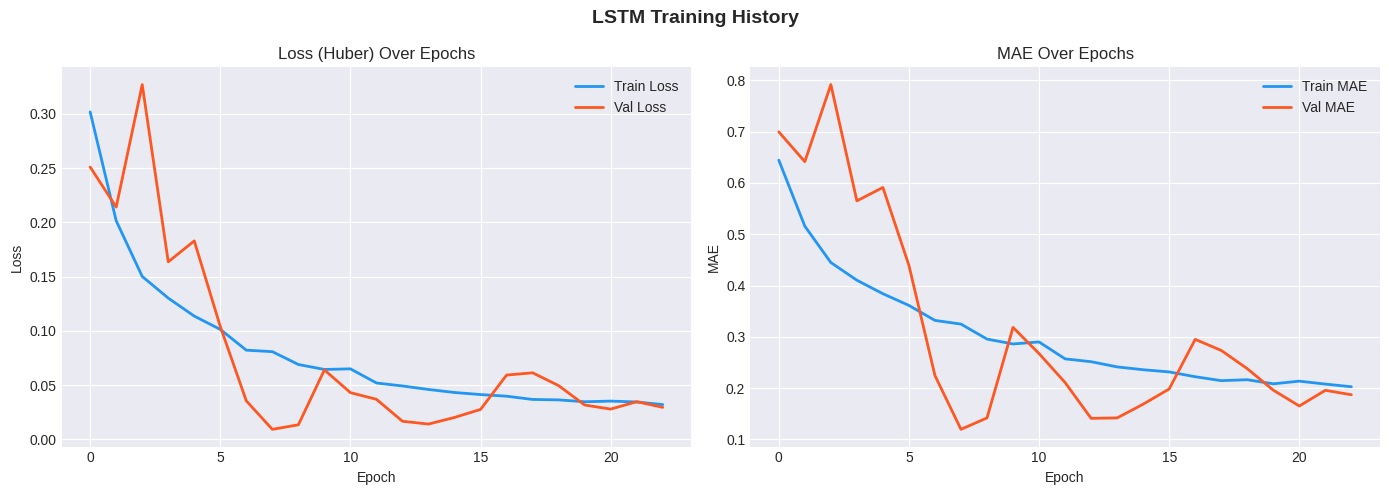

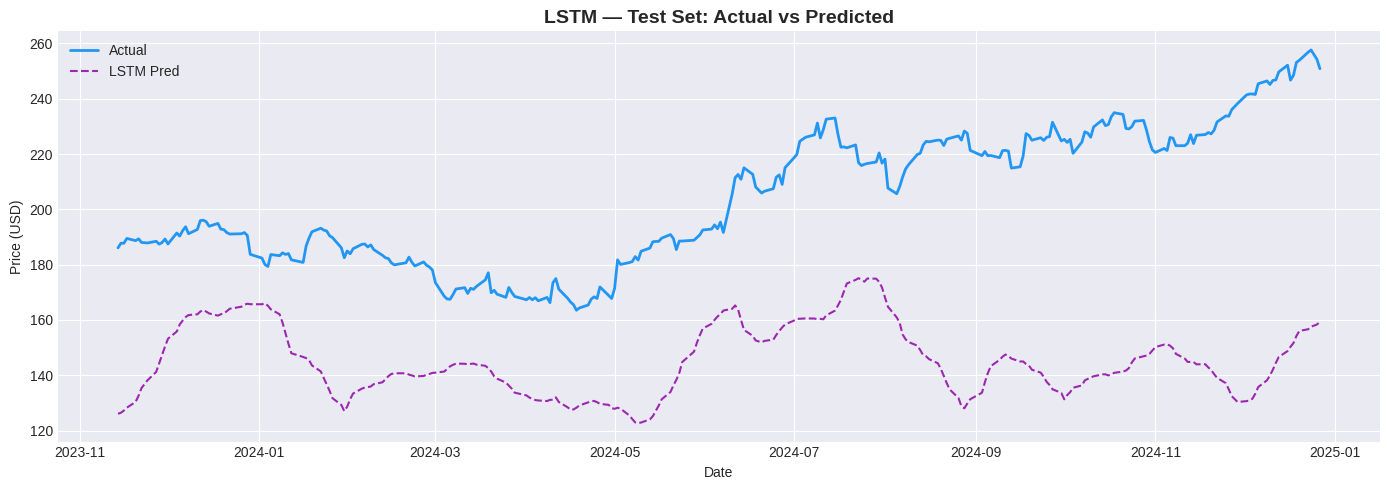

In [17]:
# ── LSTM Predictions (inverse transform back to USD prices) ───────────────────
lstm_pred_scaled = lstm_model.predict(X_test_seq, verbose=0).flatten()
lstm_pred_test   = scaler_y.inverse_transform(lstm_pred_scaled.reshape(-1, 1)).flatten()

lstm_results = evaluate_model(y_test_trimmed, lstm_pred_test, 'LSTM')

# ── Plot Training History ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM Training History', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'],     label='Train Loss', color=COLORS[0], linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   color=COLORS[2], linewidth=2)
axes[0].set_title('Loss (Huber) Over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE', color=COLORS[0], linewidth=2)
axes[1].plot(history.history['val_mae'], label='Val MAE',   color=COLORS[2], linewidth=2)
axes[1].set_title('MAE Over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

# ── LSTM Prediction Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(test_dates_trimmed, y_test_trimmed, label='Actual',    color=COLORS[0], linewidth=2)
plt.plot(test_dates_trimmed, lstm_pred_test, label='LSTM Pred', color=COLORS[3], linewidth=1.5, linestyle='--')
plt.title('LSTM — Test Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
## 🏆 Step 9: Model Comparison & Evaluation

We compare all three models using four key metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **MAE** | Mean\|y - ŷ\| | Average absolute dollar error |
| **RMSE** | √Mean(y−ŷ)² | Penalizes large errors more than MAE |
| **MAPE** | Mean\|y−ŷ\|/y × 100 | Percentage error — scale-independent |
| **R²** | 1 − SS_res/SS_tot | 1.0 = perfect; 0 = baseline mean model |

Lower MAE/RMSE/MAPE = better. Higher R² = better.

In [18]:
# ── Align all test predictions to the same index (LSTM loses first LOOK_BACK rows) ─
# We use the trimmed test set for a fair comparison on the same rows
lr_pred_trimmed = lr_pred_test[LOOK_BACK:]
rf_pred_trimmed = rf_pred_test[LOOK_BACK:]

# Recompute metrics on the aligned test set
results_list = [
    evaluate_model(y_test_trimmed, lr_pred_trimmed,  'Linear Regression'),
    evaluate_model(y_test_trimmed, rf_pred_trimmed,  'Random Forest'),
    evaluate_model(y_test_trimmed, lstm_pred_test,   'LSTM'),
]

results_df = pd.DataFrame(results_list).set_index('Model')
print("\n📋 Model Comparison Summary:")
results_df.round(4)


  Linear Regression — Test Set Metrics
  MAE  (Mean Absolute Error)       : $2.0785
  MSE  (Mean Squared Error)        : $7.9583
  RMSE (Root Mean Squared Error)   : $2.8210
  MAPE (Mean Abs Percentage Error) : 1.0216%
  R²   (Coefficient of Det.)       : 0.986678

  Random Forest — Test Set Metrics
  MAE  (Mean Absolute Error)       : $19.3474
  MSE  (Mean Squared Error)        : $729.6892
  RMSE (Root Mean Squared Error)   : $27.0128
  MAPE (Mean Abs Percentage Error) : 8.5823%
  R²   (Coefficient of Det.)       : -0.221508

  LSTM — Test Set Metrics
  MAE  (Mean Absolute Error)       : $58.7146
  MSE  (Mean Squared Error)        : $4045.5142
  RMSE (Root Mean Squared Error)   : $63.6044
  MAPE (Mean Abs Percentage Error) : 27.9887%
  R²   (Coefficient of Det.)       : -5.772238

📋 Model Comparison Summary:


,MAE,RMSE,MAPE,R2
Model,,,,
Linear Regression,2.0785,2.8210,1.0216,0.9867
Random Forest,19.3474,27.0128,8.5823,-0.2215
LSTM,58.7146,63.6044,27.9887,-5.7722


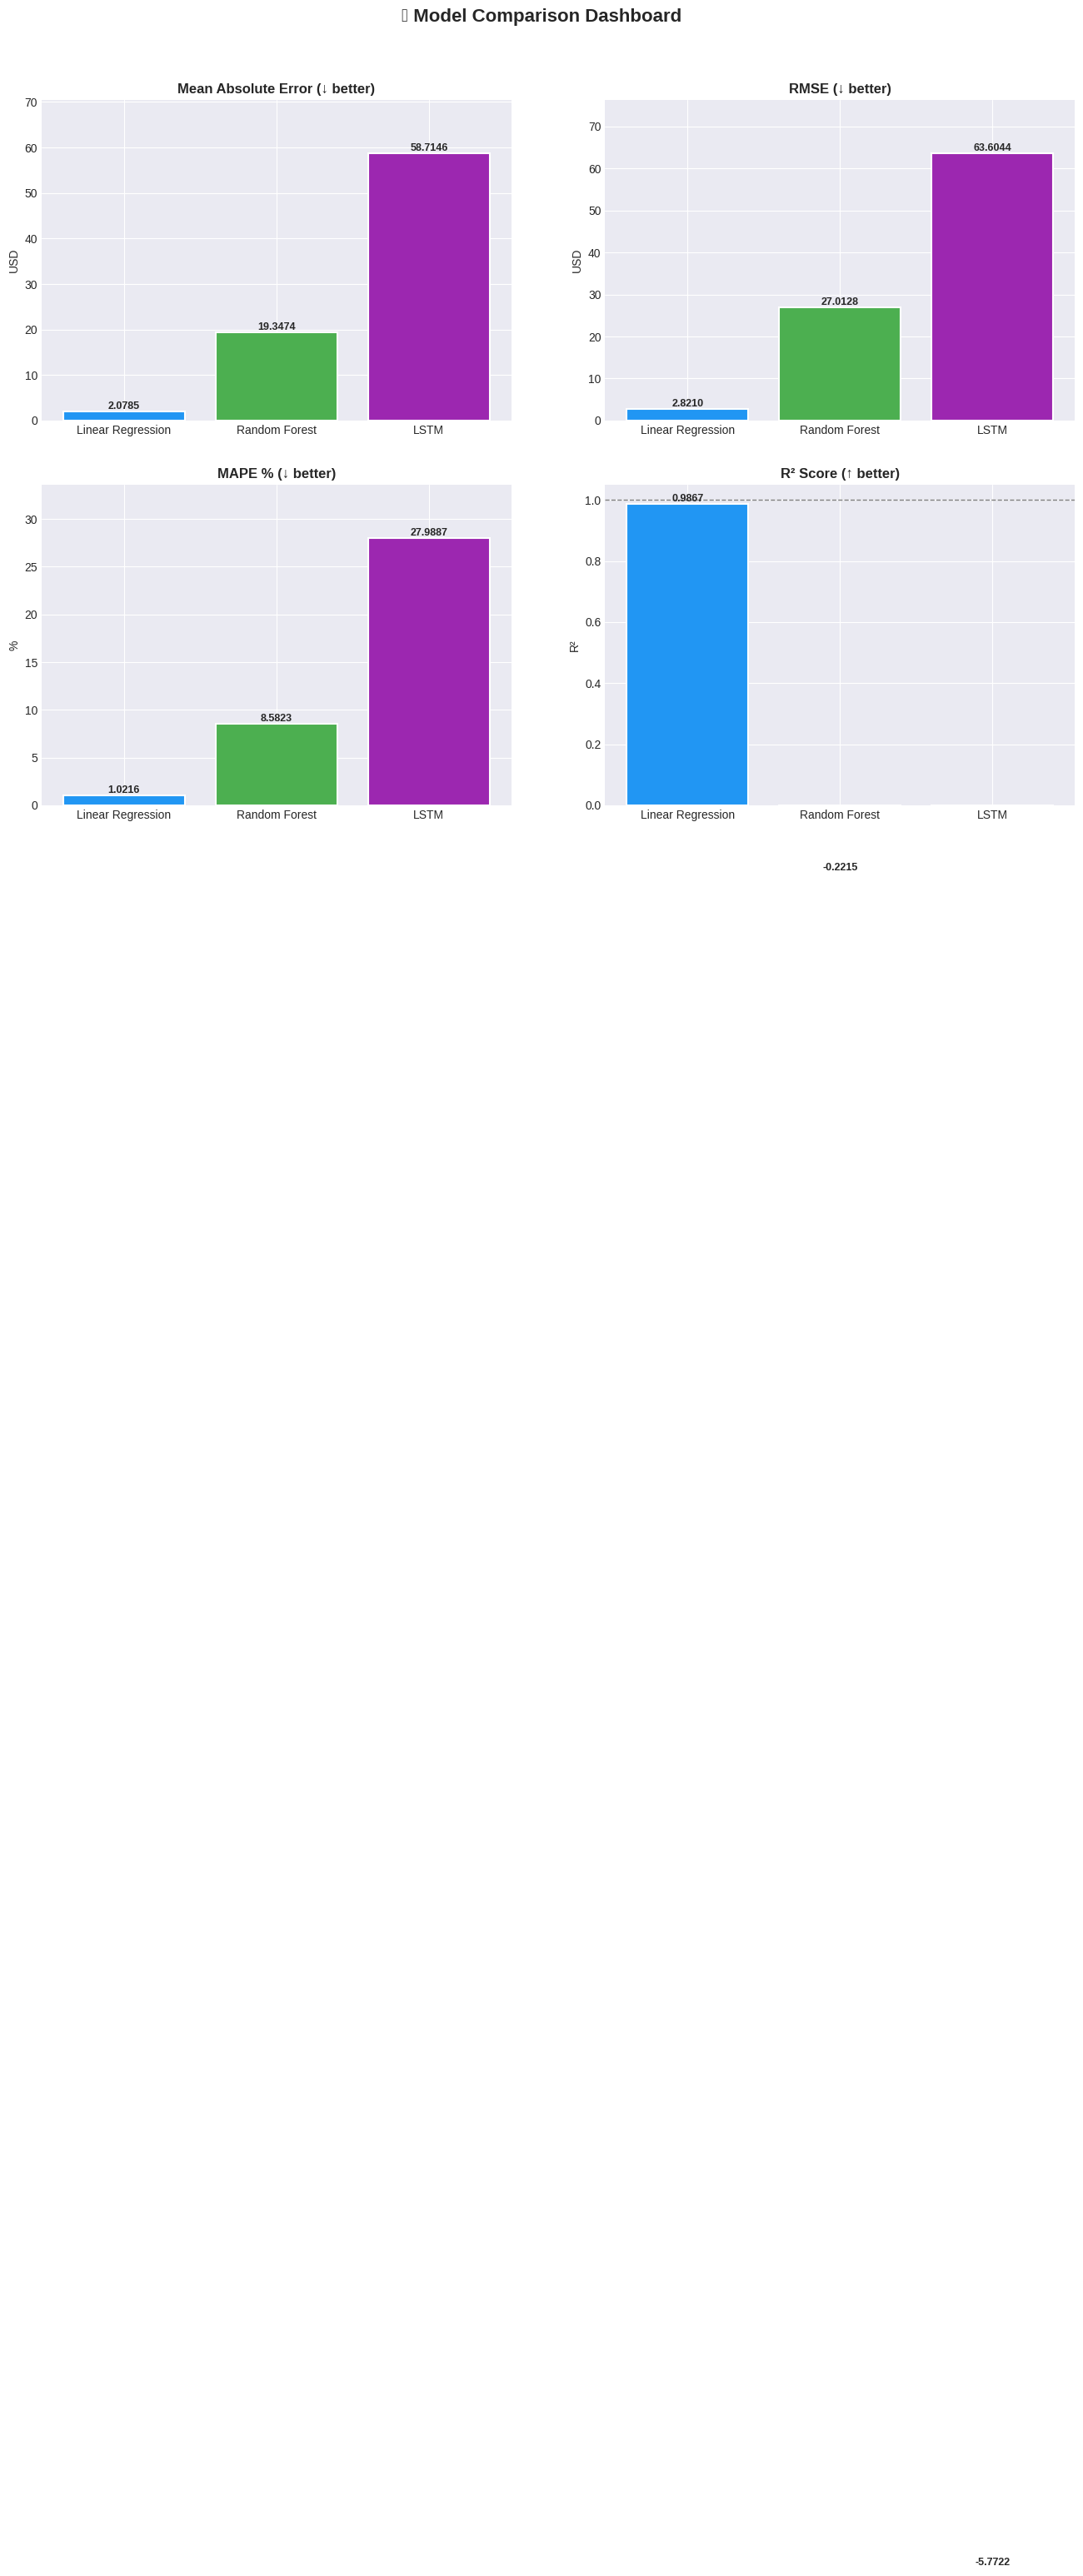

In [19]:
# ── Comparison Charts ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('📊 Model Comparison Dashboard', fontsize=16, fontweight='bold')

models    = results_df.index.tolist()
model_colors = [COLORS[0], COLORS[1], COLORS[3]]

# Bar charts for each metric
for ax, metric, title, ylabel in zip(
    [axes[0,0], axes[0,1], axes[1,0]],
    ['MAE', 'RMSE', 'MAPE'],
    ['Mean Absolute Error (↓ better)', 'RMSE (↓ better)', 'MAPE % (↓ better)'],
    ['USD', 'USD', '%']
):
    bars = ax.bar(models, results_df[metric], color=model_colors, edgecolor='white', linewidth=1.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_ylim(0, results_df[metric].max() * 1.2)

# R² chart
bars = axes[1,1].bar(models, results_df['R2'], color=model_colors, edgecolor='white', linewidth=1.5)
axes[1,1].set_title('R² Score (↑ better)', fontsize=12, fontweight='bold')
axes[1,1].set_ylabel('R²')
axes[1,1].axhline(1.0, color='gray', linestyle='--', linewidth=1)
for bar, val in zip(bars, results_df['R2']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[1,1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

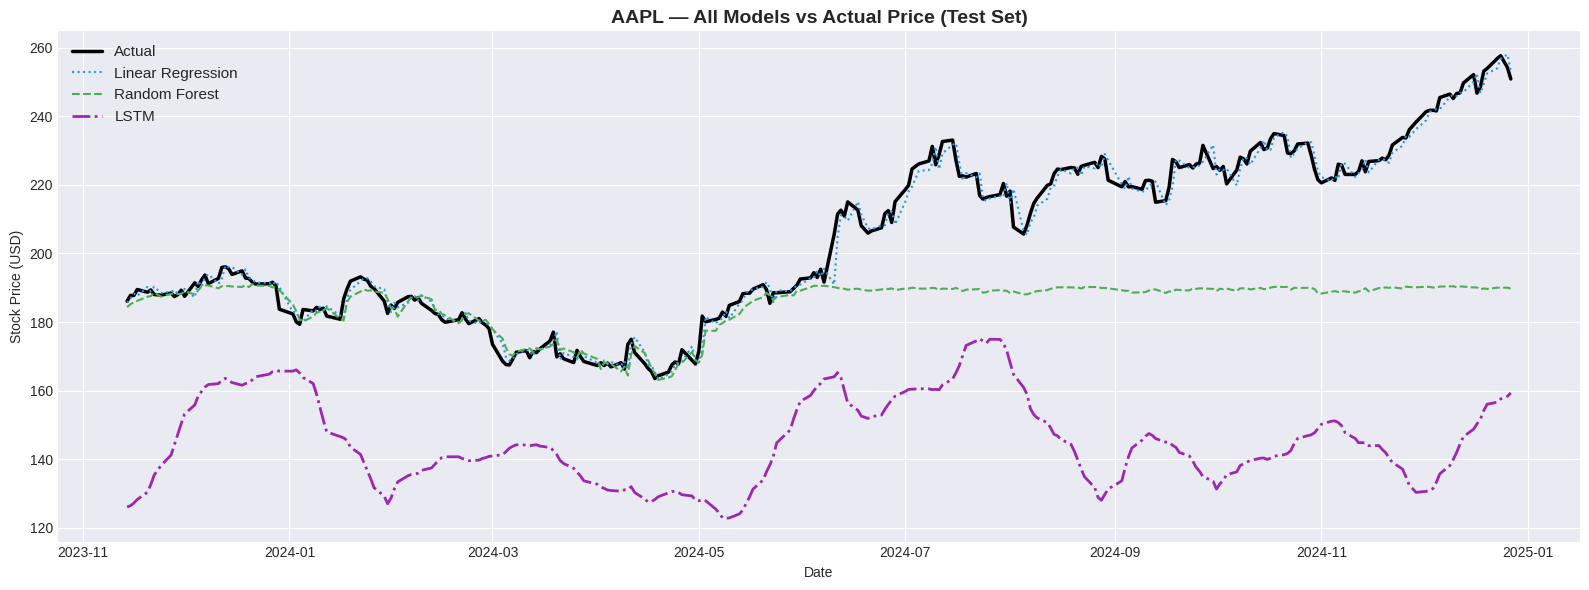


🏆 BEST MODEL (lowest RMSE): Linear Regression
MAE     2.078487
RMSE    2.821038
MAPE    1.021586
R2      0.986678


In [20]:
# ── All Models on One Chart ───────────────────────────────────────────────────
plt.figure(figsize=(16, 6))

plt.plot(test_dates_trimmed, y_test_trimmed,   label='Actual',           color='black',     linewidth=2.5)
plt.plot(test_dates_trimmed, lr_pred_trimmed,  label='Linear Regression', color=COLORS[0],  linewidth=1.5, linestyle=':')
plt.plot(test_dates_trimmed, rf_pred_trimmed,  label='Random Forest',    color=COLORS[1],   linewidth=1.5, linestyle='--')
plt.plot(test_dates_trimmed, lstm_pred_test,   label='LSTM',             color=COLORS[3],   linewidth=2,   linestyle='-.')

plt.title(f'{TICKER} — All Models vs Actual Price (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Determine best model ──────────────────────────────────────────────────────
best_model_name = results_df['RMSE'].idxmin()
print(f"\n🏆 BEST MODEL (lowest RMSE): {best_model_name}")
print(results_df.loc[best_model_name].to_string())

---
## 🔮 Step 10: Future Price Prediction

Using the best-performing model, we predict the **next N trading days** of stock prices.

**Method:**
- Take the most recent `LOOK_BACK` days as our input window.
- Predict day T+1, append it, slide the window, predict T+2, and so on.
- This is called **auto-regressive multi-step forecasting**.

> ⚠️ **Disclaimer:** These predictions are for educational purposes only. Stock markets are influenced by news, sentiment, macroeconomics, and events that models cannot capture. Do not use this for actual trading decisions.

In [21]:
FORECAST_DAYS = 30   # Number of future trading days to predict

print(f"🔮 Generating {FORECAST_DAYS}-day forecast using LSTM ...")

# Use the final LOOK_BACK rows of the full scaled dataset as our starting window
full_X_scaled = scaler_X.transform(X)
current_seq   = full_X_scaled[-LOOK_BACK:].copy()   # shape: (60, n_features)

future_preds_scaled = []

for day in range(FORECAST_DAYS):
    # Reshape to (1, look_back, n_features)
    input_seq  = current_seq.reshape(1, LOOK_BACK, n_features)

    # Predict next normalized price
    pred_scaled = lstm_model.predict(input_seq, verbose=0)[0, 0]
    future_preds_scaled.append(pred_scaled)

    # Slide window: drop oldest row, append a new row
    # For future rows, we copy the last row and update the Close-related features
    new_row = current_seq[-1].copy()
    # Update the Close column (index of 'Close' in FEATURE_COLS)
    close_idx = FEATURE_COLS.index('Close')
    new_row[close_idx] = pred_scaled   # Use predicted close as next day's input
    current_seq = np.vstack([current_seq[1:], new_row])

# Inverse transform predictions back to USD
future_prices = scaler_y.inverse_transform(
    np.array(future_preds_scaled).reshape(-1, 1)
).flatten()

# Generate future business dates
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_DAYS)

print(f"✅ Forecast complete!")
print(f"\n📅 Predictions: {future_dates[0].date()} → {future_dates[-1].date()}")
print(f"💰 Starting price : ${future_prices[0]:.2f}")
print(f"💰 Ending price   : ${future_prices[-1]:.2f}")
print(f"📊 Predicted trend: {'📈 UP' if future_prices[-1] > future_prices[0] else '📉 DOWN'} by ${abs(future_prices[-1]-future_prices[0]):.2f}")

🔮 Generating 30-day forecast using LSTM ...
✅ Forecast complete!

📅 Predictions: 2024-12-30 → 2025-02-07
💰 Starting price : $161.15
💰 Ending price   : $177.73
📊 Predicted trend: 📈 UP by $16.58


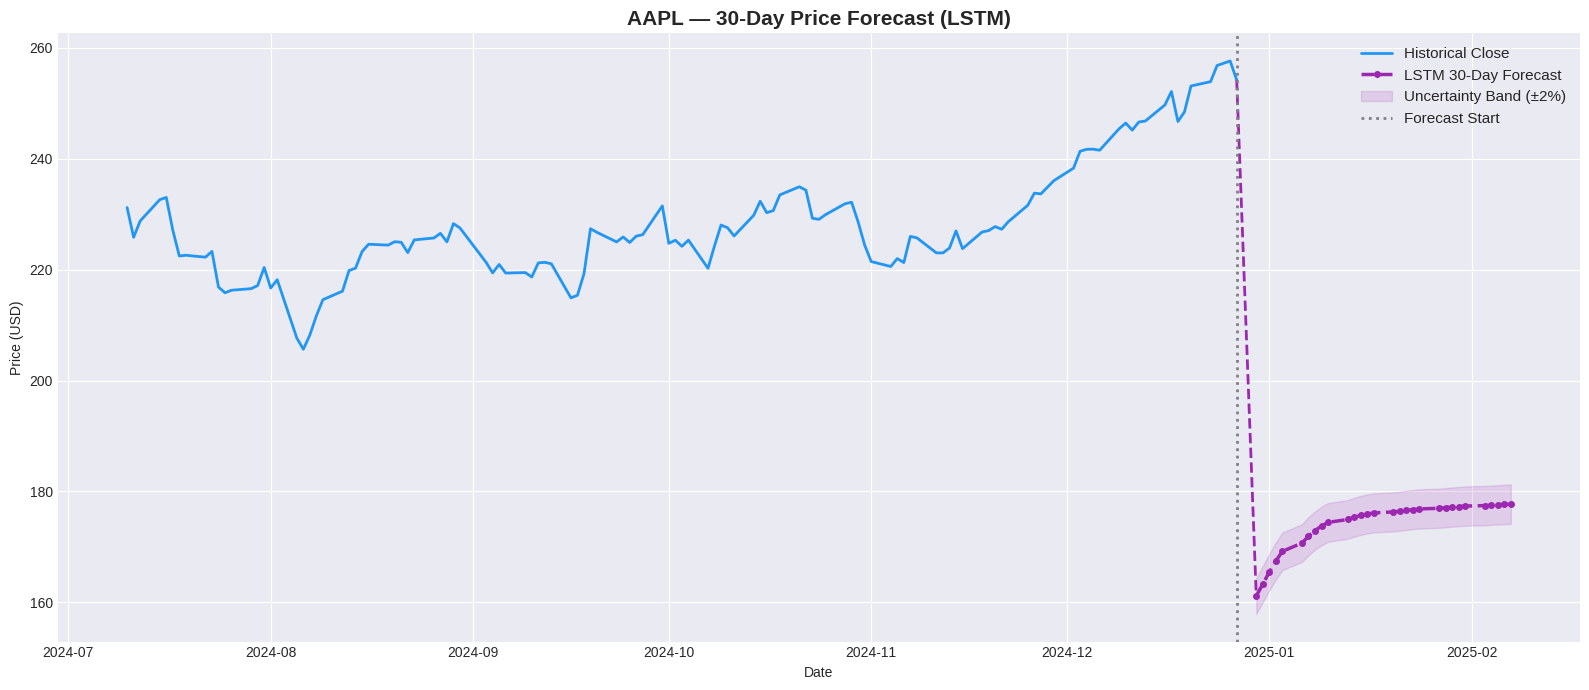


📋 30-Day Forecast Table:
      Date  Predicted_Close  Change  Change_%
2024-12-30       161.149994    0.00     0.000
2024-12-31       163.309998    2.16     1.340
2025-01-01       165.479996    2.17     1.329
2025-01-02       167.460007    1.98     1.197
2025-01-03       169.210007    1.75     1.045
2025-01-06       170.699997    1.49     0.881
2025-01-07       171.940002    1.24     0.726
2025-01-08       172.960007    1.02     0.593
2025-01-09       173.779999    0.82     0.474
2025-01-10       174.429993    0.65     0.374
2025-01-13       174.949997    0.52     0.298
2025-01-14       175.360001    0.41     0.234
2025-01-15       175.690002    0.33     0.188
2025-01-16       175.940002    0.25     0.142
2025-01-17       176.139999    0.20     0.114
2025-01-20       176.309998    0.17     0.097
2025-01-21       176.449997    0.14     0.079
2025-01-22       176.600006    0.15     0.085
2025-01-23       176.729996    0.13     0.074
2025-01-24       176.860001    0.13     0.074
2025-01-

In [22]:
# ── Future Forecast Visualization ─────────────────────────────────────────────
HISTORY_DAYS = 120   # Days of historical context to show

hist_dates  = df.index[-HISTORY_DAYS:]
hist_prices = df['Close'].values[-HISTORY_DAYS:]

plt.figure(figsize=(16, 7))

# Historical prices
plt.plot(hist_dates, hist_prices, label='Historical Close', color=COLORS[0], linewidth=2)

# Bridge (last actual + first forecast)
plt.plot([hist_dates[-1], future_dates[0]],
         [hist_prices[-1], future_prices[0]],
         color=COLORS[3], linewidth=2, linestyle='--')

# Future predictions
plt.plot(future_dates, future_prices, label=f'LSTM {FORECAST_DAYS}-Day Forecast',
         color=COLORS[3], linewidth=2.5, linestyle='--', marker='o', markersize=4)

# Confidence band (±2% for illustrative purposes)
upper = future_prices * 1.02
lower = future_prices * 0.98
plt.fill_between(future_dates, lower, upper, alpha=0.15, color=COLORS[3], label='Uncertainty Band (±2%)')

# Vertical line separating history from forecast
plt.axvline(x=last_date, color='gray', linestyle=':', linewidth=2, label='Forecast Start')

plt.title(f'{TICKER} — {FORECAST_DAYS}-Day Price Forecast (LSTM)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ── Forecast Table ─────────────────────────────────────────────────────────────
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Close': future_prices.round(2)})
forecast_df['Date'] = forecast_df['Date'].dt.strftime('%Y-%m-%d')
forecast_df['Change'] = forecast_df['Predicted_Close'].diff().fillna(0).round(2)
forecast_df['Change_%'] = (forecast_df['Change'] / forecast_df['Predicted_Close'].shift(1) * 100).fillna(0).round(3)

print("\n📋 30-Day Forecast Table:")
print(forecast_df.to_string(index=False))

---
## 📝 Step 11: Summary & Key Takeaways

This section summarizes everything we accomplished and highlights the most important lessons.

In [23]:
print("=" * 60)
print("      📈 STOCK PRICE PREDICTION — PROJECT SUMMARY")
print("=" * 60)

print(f"""
📌 STOCK     : {TICKER}
📅 PERIOD    : {START_DATE} → {END_DATE}
📊 FEATURES  : {len(FEATURE_COLS)} engineered technical indicators
🎯 TARGET    : Next-day closing price
""")

print("─" * 60)
print("  MODEL PERFORMANCE (Test Set):")
print("─" * 60)
print(results_df.round(4).to_string())

print(f"""
─────────────────────────────────────────────────────────────
  🏆 BEST MODEL: {results_df['RMSE'].idxmin()}
─────────────────────────────────────────────────────────────

💡 KEY TAKEAWAYS:

  1. Feature Engineering is crucial — technical indicators
     (RSI, MACD, Bollinger Bands) significantly boost accuracy.

  2. NEVER shuffle time-series data — temporal ordering must
     be preserved to avoid data leakage.

  3. Scale features before training neural networks — MinMax
     scaling on training data only prevents leakage.

  4. LSTM excels at capturing sequential dependencies in stock
     data but requires more data and training time.

  5. Random Forest provides fast, interpretable results with
     built-in feature importance ranking.

  6. Always inverse-transform predictions to get real USD values
     before computing metrics.

  7. High R² doesn't mean the model captures market direction
     — consider directional accuracy for trading applications.

⚠️ DISCLAIMER: Predictions are for educational purposes ONLY.
   Stock markets are inherently unpredictable. Never invest based
   solely on ML model outputs.
""")
print("=" * 60)

      📈 STOCK PRICE PREDICTION — PROJECT SUMMARY

📌 STOCK     : AAPL
📅 PERIOD    : 2018-01-01 → 2024-12-31
📊 FEATURES  : 30 engineered technical indicators
🎯 TARGET    : Next-day closing price

────────────────────────────────────────────────────────────
  MODEL PERFORMANCE (Test Set):
────────────────────────────────────────────────────────────
                       MAE     RMSE     MAPE      R2
Model                                               
Linear Regression   2.0785   2.8210   1.0216  0.9867
Random Forest      19.3474  27.0128   8.5823 -0.2215
LSTM               58.7146  63.6044  27.9887 -5.7722

─────────────────────────────────────────────────────────────
  🏆 BEST MODEL: Linear Regression
─────────────────────────────────────────────────────────────

💡 KEY TAKEAWAYS:

  1. Feature Engineering is crucial — technical indicators
     (RSI, MACD, Bollinger Bands) significantly boost accuracy.

  2. NEVER shuffle time-series data — temporal ordering must
     be preserved to avo